# Assignment: Tuning Curves and Place Cells (Code Only)


In [1]:

import numpy as np
import scipy
import scipy.stats
import scipy.io
import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets
from tqdm import tqdm
import seaborn as sns
import pickle
import sys
import os

sys.path.append(os.path.abspath("../01-tuning-curves/code"))
from utils import download_data


sns.set_theme(context='notebook', style='white', font_scale=1.5,
              rc={'axes.spines.top': False, 'axes.spines.right': False})


download_data('https://surfdrive.surf.nl/files/index.php/s/z7mMiznEWOT0Iak')


## Exercise 1 - simulating place cells
---
Use the code we build to simulate place cells in the lesson.

A - Explore what happens when you change the binning in the definition of the firing rate maps (`space_bins`). Make it coarser or broader. 


B - In the spike train simulations, we add some "baseline" noise, not place-related to the firing. Which variable determines the noise level? Try to experiment with that variable and see what happens to the firing rate maps. What is the best approach to firing rate maps when the noise is high.


C - We could use other approaches to firing rate maps: for example make the binning very small (down to 1 cm, which is the resolution of our "video" data, and then applying a gaussian smoother. Scipy has a Gaussian smoother at `scipy.stats.gaussian_kde`. Read the documentation for that function and apply it to the data to define the smoothed firing rate maps. Again, change the noise levels and see how the smoother changes. 

D - When analyzing place fields, two important quantities are the place field center and the place field width. The place field center may be defined in many ways, but one is to compute the "center of mass" of the spikes according to the equation 

$$ c_{pf} = \frac{1}{N_{spikes}} \sum_{i} L_i $$ 

where the sum on $i$ runs on all spikes emitted by a cell and $L_i$ is the location at which the i-th spike was emitted. Calculate this for each cell. Compare with the "true" place field centers from the simulations (which variables are we talking about?) 


In [2]:
track_length = 200. # the length of our linear track (eg in centimeter)
average_firing_rate = 5 # the peak firing rate, averaged across the population 
n_cells = 100 # how many cells we are recording
pf_centers = np.random.rand(n_cells) * track_length # the centers of the place fields for all cells drawn randomly with a uniform distribution on the track
pf_size = np.random.gamma(10, size=n_cells) # the size (width) of the place fields, drawn randomly from a gamma distribution 
pf_rate = np.random.exponential(scale=average_firing_rate, size=n_cells) # the peak firing rate for each cell, drawn from an exponential distribution



Text(0, 0.5, 'Probability')

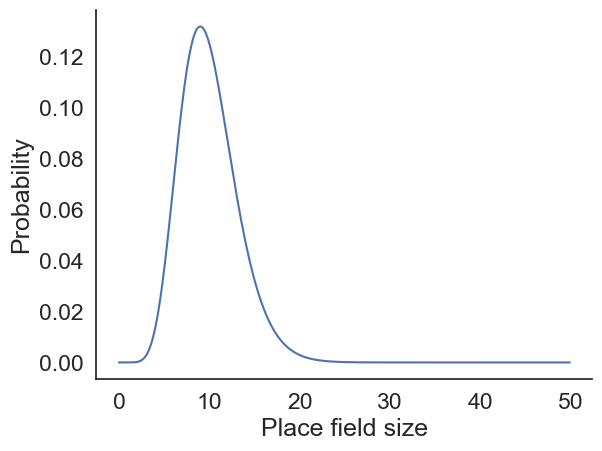

In [3]:
x_grid = np.arange(0., 50., 0.1) # we use a grid with step 0.1
g = scipy.stats.gamma.pdf(x_grid, 10)
plt.plot(x_grid, g)
plt.xlabel('Place field size')
plt.ylabel('Probability')

## 1.A Changing the binning size

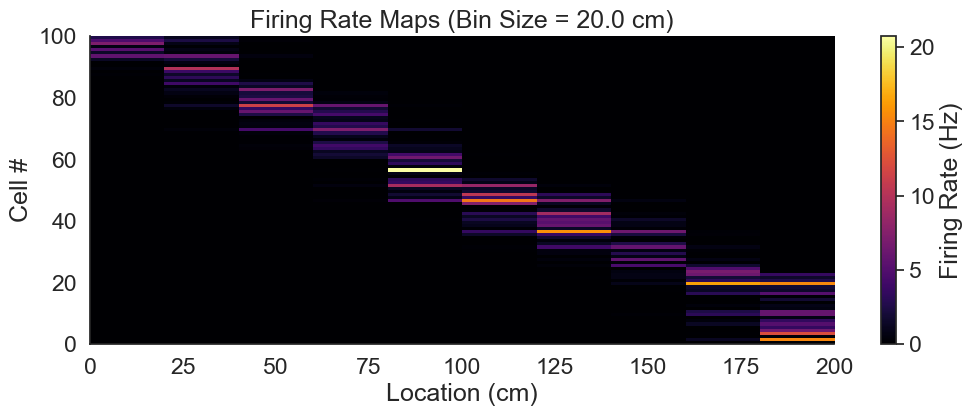

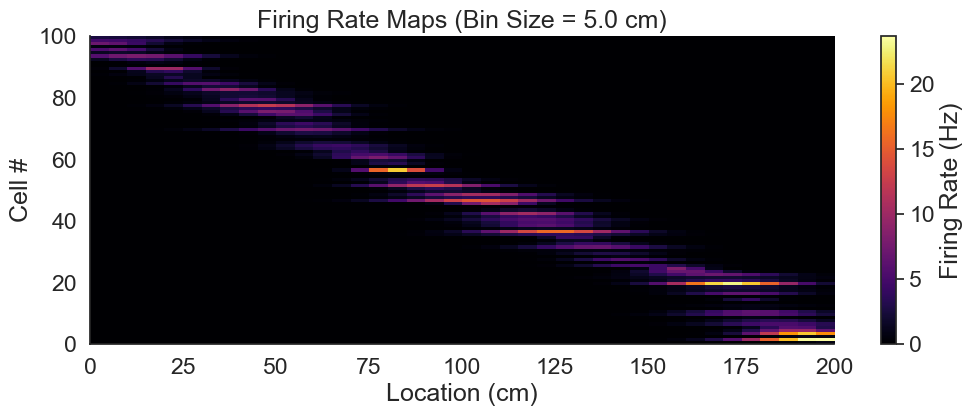

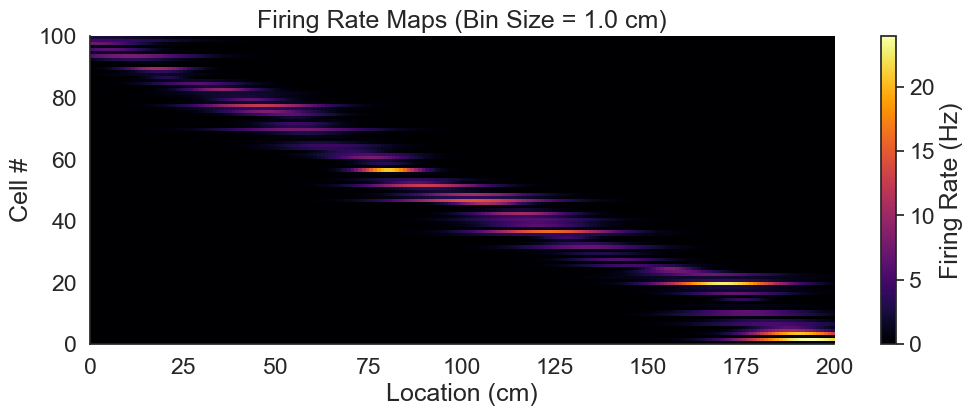

In [4]:

# We will test three different bin sizes to see how spatial resolution changes
bin_sizes_to_test = [20.0, 5.0, 1.0]

for bin_size in bin_sizes_to_test:
    

    bins = np.arange(0., 200., bin_size)
    
    
    true_firing_rate_maps = np.zeros((n_cells, len(bins)))
    for i in range(n_cells):
        true_firing_rate_maps[i,:] = pf_rate[i] * np.exp(-((bins-pf_centers[i])**2)/(2*pf_size[i]**2))
        
    #Sorting by its center
    ix = np.argsort(pf_centers)
    
    # Plot
    plt.figure(figsize=(12, 4))
    plt.imshow(true_firing_rate_maps[ix,:], cmap='inferno', extent=[0, 200, 0, n_cells], aspect='auto')
    plt.xlabel('Location (cm)')
    plt.ylabel('Cell #')
    plt.title(f'Firing Rate Maps (Bin Size = {bin_size} cm)')
    plt.colorbar(label='Firing Rate (Hz)')
    plt.show()




In [5]:
n_runs = 20 
av_running_speed = 10 # the average running speed (in cm/s)
fps = 30 # the number of "video frames" per second 
running_speed_a = np.random.chisquare(10, size=n_runs) # running speed in the two directions
running_speed_b = np.random.chisquare(10, size=n_runs) 

stopping_time_a = np.random.chisquare(15, size=n_runs) # the time the mouse will spend at the two ends of the track
stopping_time_b = np.random.chisquare(15, size=n_runs)

x = np.array([])
for i in range(n_runs):
    stop1 = np.ones((int(stopping_time_a[i]*fps),)) * 0.
    run_length = len(bins) * fps / running_speed_a[i]
    run1 = np.linspace(0., float(len(bins)-1), int(run_length))
    stop2 = np.ones((int(stopping_time_b[i]*fps),)) * (len(bins)-1.)
    run_length = len(bins) * fps / running_speed_b[i]
    run2 = np.linspace(len(bins)-1., 0., int(run_length))
    x = np.concatenate((x, stop1, run1, stop2, run2))
t = np.arange(len(x))/fps

## Observations on bin size:
 Smaller bin sizes have higher spatial accuracy, allowing us to distinguish neurons that fire in highly specific locations (e.g. 1 cm bins). Alternatively, larger bin sizes allow more spikes to fall into a single bin. This is less spatially accurate and blurs the firing rate map (e.g. 20 cm bins)

## 1B. Baseline Noise levels

Noise 0.1 Hz: 100%|██████████| 100/100 [00:57<00:00,  1.74it/s]


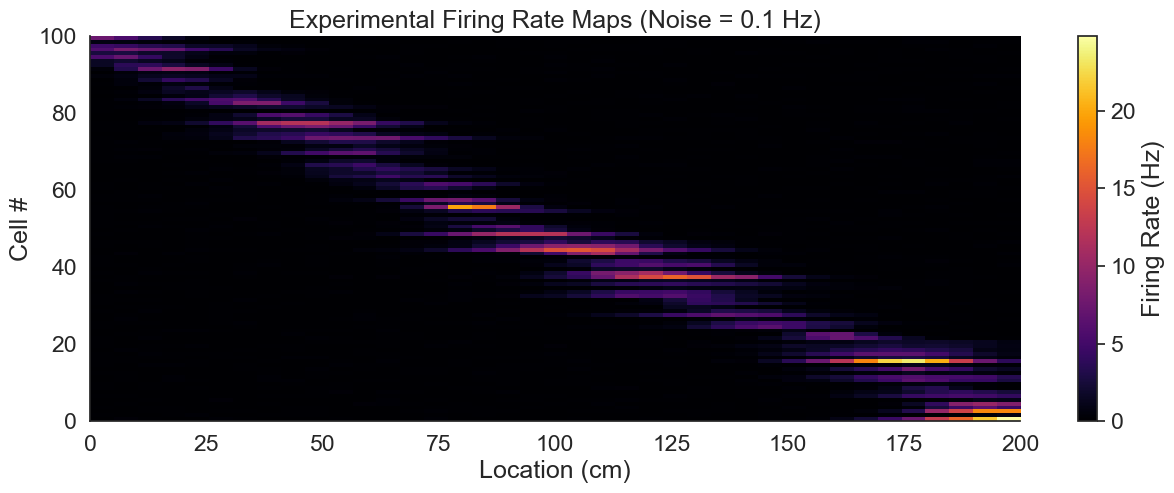

Noise 2.0 Hz: 100%|██████████| 100/100 [00:47<00:00,  2.13it/s]


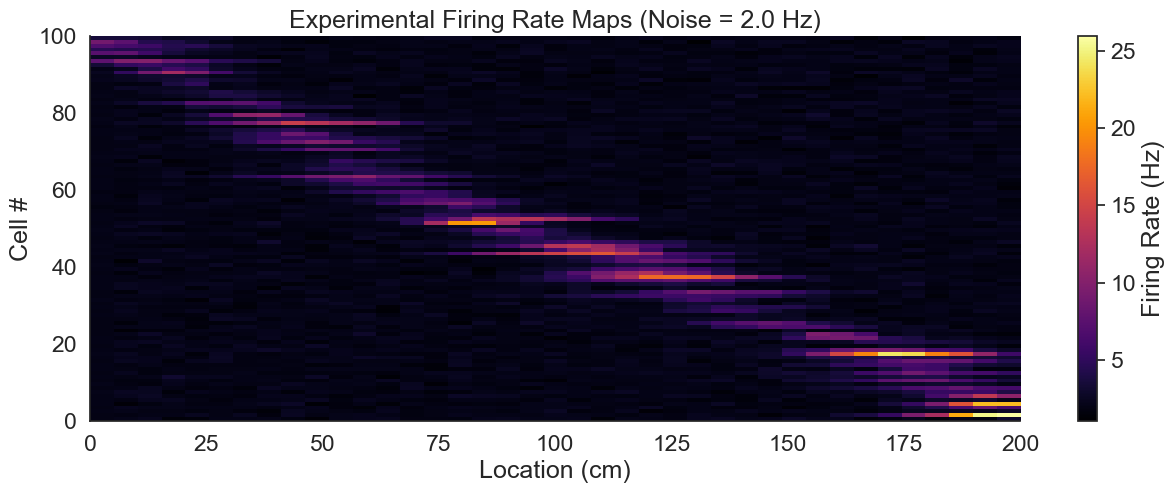

Noise 10.0 Hz: 100%|██████████| 100/100 [00:46<00:00,  2.14it/s]


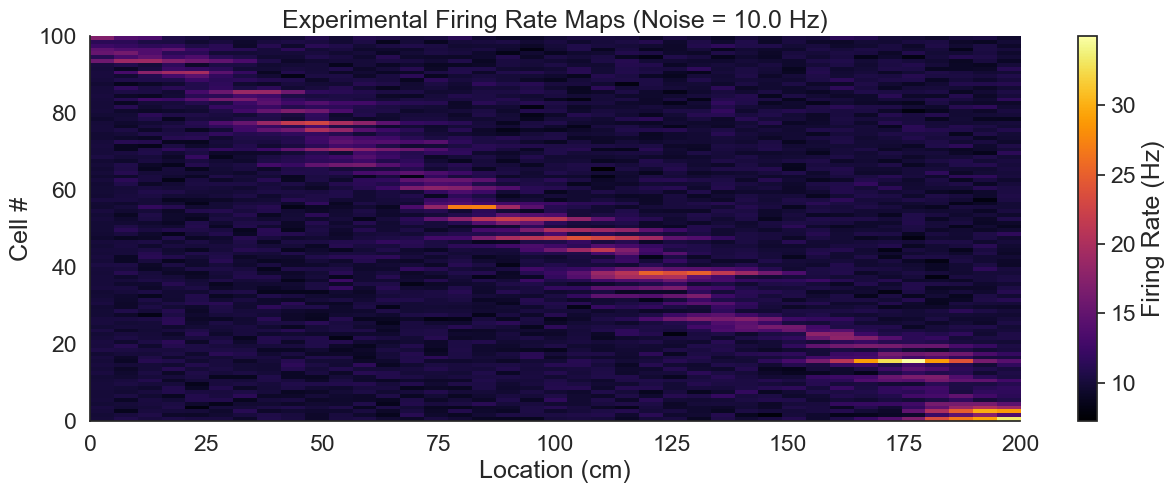

In [6]:
# Varying noise levels. 

# Define the basic sampling variables
sampling_rate = 10000.
t_sampling = np.arange(0, t[-1], 1. / sampling_rate)
x_sampling = np.floor(np.interp(t_sampling, t, x))

space_bins = np.arange(0., 200., 5.)

# Calculate occupancy 
occupancy = np.histogram(x, space_bins)[0] / fps
occupancy[occupancy == 0] = 0.001 # Avoid divide-by-zero errors

# We will test Low, Medium, and High noise environments
noise_levels_to_test = [0.1, 2.0, 10.0]

for current_noise in noise_levels_to_test:
    
    
    spikes = []
    
   
    for i in tqdm(range(n_cells), desc=f"Noise {current_noise} Hz"):
        inst_rate = true_firing_rate_maps[i, x_sampling.astype(np.int32)] + current_noise
        spikes_loc = np.random.poisson(inst_rate / sampling_rate)
        sp = np.argwhere(spikes_loc)
        t_sp = t_sampling[sp]
        spikes.append(t_sp)
        
    
    spike_positions = [np.interp(s, t, x) for s in spikes]
    
    # Histograms
    spikes_hist = [np.histogram(s, space_bins)[0] for s in spike_positions]
    spikes_hist = np.vstack(spikes_hist).astype(np.float64)
    
    # Firing rate maps
    firing_rate_maps = spikes_hist / occupancy
    
    # Sort the cells by peak locations
    peak_locations = firing_rate_maps.argmax(axis=1)
    ix = np.argsort(peak_locations)
    
    # Plot
    plt.figure(figsize=(15, 5))
    plt.imshow(firing_rate_maps[ix,:], cmap='inferno', extent=[0, 200, 0, n_cells], aspect='auto')
    plt.xlabel('Location (cm)')
    plt.ylabel('Cell #')
    plt.title(f'Experimental Firing Rate Maps (Noise = {current_noise} Hz)')
    plt.colorbar(label='Firing Rate (Hz)')
    plt.show()




## Observations on baseline noise levels: 
The variable that determines the baseline noise in the lesson is noise_firing_rate. Here, we use the variable noise_levels_to_test to explore different noise intensities. As baseline noise increases, the firing rate maps become more unselective for spatial locations, making it difficult to identify distinct place fields. 

Note: The bin size is set to 5

## 1.C Gaussian Smoother

Noise 0.1 Hz: 100%|██████████| 100/100 [01:02<00:00,  1.59it/s]


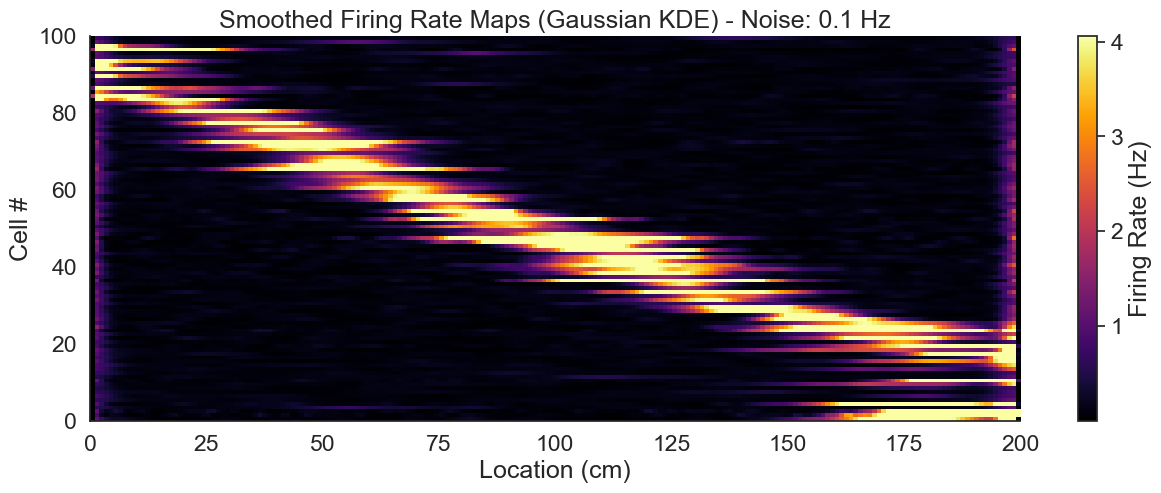

Noise 2.0 Hz: 100%|██████████| 100/100 [01:05<00:00,  1.52it/s]


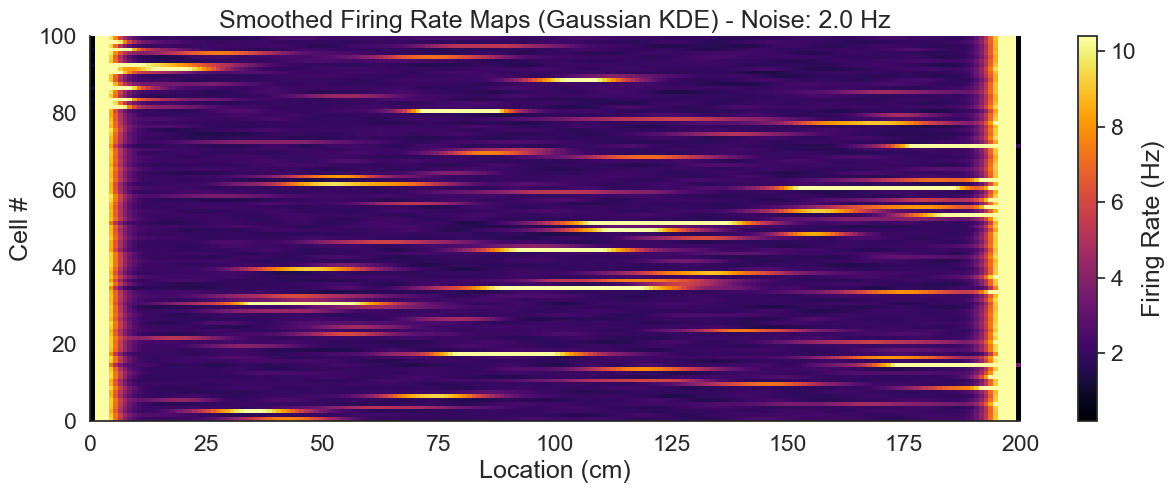

Noise 10.0 Hz: 100%|██████████| 100/100 [00:50<00:00,  1.97it/s]


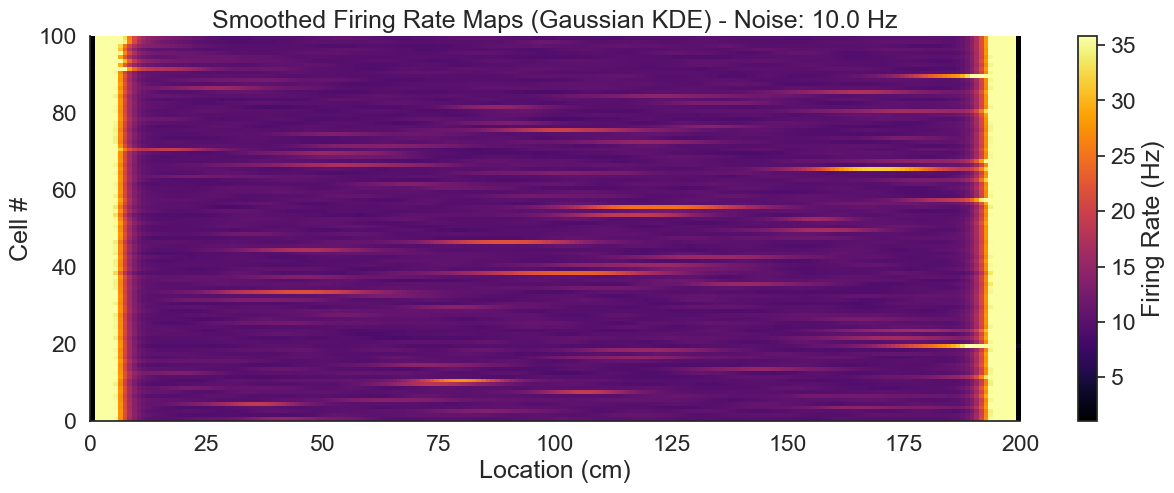

In [7]:
# We will test Low, Medium, and High noise environments with Gaussian Smoother
noise_levels_to_test = [0.1, 2.0, 10.0]

#Bin is set to 1 cm
bin_step = 1.0 


space_bins = np.arange(0., 201., bin_step)


bin_centers = (space_bins[:-1] + space_bins[1:]) / 2.0


occupancy = np.histogram(x_sampling, space_bins)[0] / sampling_rate
occupancy[occupancy == 0] = 0.001 

for current_noise in noise_levels_to_test:
    
    
    spikes = []
    for i in tqdm(range(n_cells), desc=f"Noise {current_noise} Hz"):
        inst_rate = true_firing_rate_maps[i, x_sampling.astype(np.int32)] + current_noise
        spikes_loc = np.random.poisson(inst_rate / sampling_rate)
        sp = np.argwhere(spikes_loc)
        t_sp = t_sampling[sp]
        spikes.append(t_sp)
        
    
    spike_positions = [np.interp(s, t_sampling, x_sampling) for s in spikes]
    
    # Matrix
    smoothed_firing_rate_maps = np.zeros((n_cells, len(bin_centers)))
    
    for i in range(n_cells):
        current_spike_positions = spike_positions[i]
        
       
        if len(np.unique(current_spike_positions)) > 1:
            
            
            kde_smoother = scipy.stats.gaussian_kde(current_spike_positions.flatten(), bw_method=0.05)
            
            # Evaluating the smoother at bin centers
            pdf = kde_smoother.evaluate(bin_centers)
            
            expected_spikes = pdf * len(current_spike_positions) * bin_step
            smoothed_firing_rate_maps[i, :] = expected_spikes / occupancy
            
            
            smoothed_firing_rate_maps[i, occupancy < 0.05] = 0.0
            
        else:
            smoothed_firing_rate_maps[i, :] = 0.0

    peak_locations = smoothed_firing_rate_maps.argmax(axis=1)
    ix = np.argsort(peak_locations)
    
    
    vmax_ceiling = np.percentile(smoothed_firing_rate_maps[ix,:], 95)
    
    # Plot
    plt.figure(figsize=(15, 5))
    
    plt.imshow(smoothed_firing_rate_maps[ix,:], cmap='inferno', extent=[0, 200, 0, n_cells], aspect='auto', vmax=vmax_ceiling)
    plt.xlabel('Location (cm)')
    plt.ylabel('Cell #')
    plt.title(f'Smoothed Firing Rate Maps (Gaussian KDE) - Noise: {current_noise} Hz')
    plt.colorbar(label='Firing Rate (Hz)')
    plt.show()


## Observations: 
What gaussian smoother is doing is replacing each spike with a gaussian kernel. By summing these curves togeteher and using an automatic bandwidth for the kernels smooths the firing rate map.

Increasing the baseline noise increases the number of spikes across the track (outside the center field), which makes the smoother take more spikes. Instead of filtering the noise out, the smoother blurs it making the firing rate appear unselective for spatial locations. Smoothing cannot separate signal from noise. For instance, what we can see with 10Hz of noise is a smoother version of the noise. 


In [8]:
# Reset to a clean baseline noise
noise_firing_rate = 0.1
spikes = []

# Re-simulate the spikes with low noise
for i in range(n_cells):
    inst_rate = true_firing_rate_maps[i, x_sampling.astype(np.int32)] + noise_firing_rate
    spikes_loc = np.random.poisson(inst_rate / sampling_rate)
    sp = np.argwhere(spikes_loc)
    t_sp = t_sampling[sp]
    spikes.append(t_sp)

# Overwrite the memory with the clean spike positions
spike_positions = [np.interp(s, t, x) for s in spikes]


## 1.D Center mass calculation

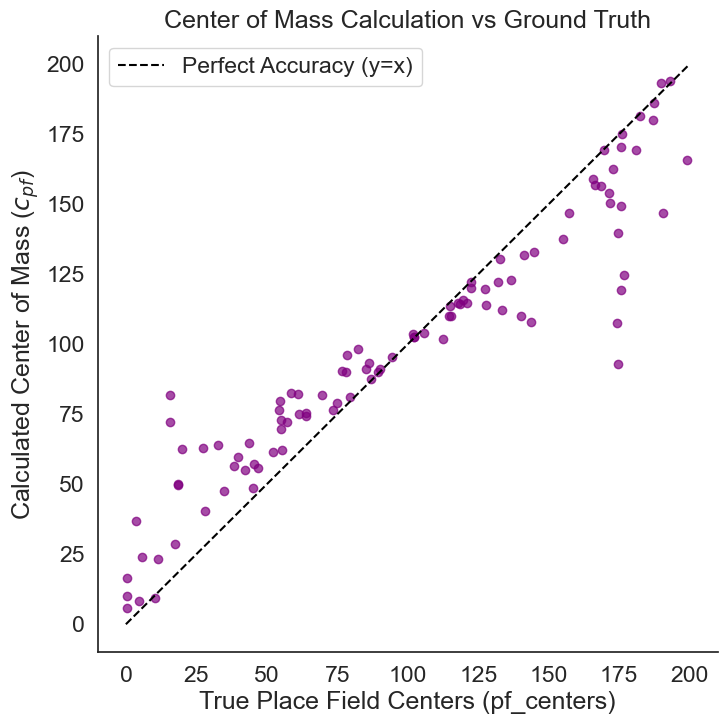

In [9]:


calculated_centers = []

# Calculate the Center of Mass for each cell
for i in range(n_cells):
    current_spike_positions = spike_positions[i]
    
    
    if len(current_spike_positions) > 0:
       
        center_of_mass = np.mean(current_spike_positions)
        calculated_centers.append(center_of_mass)
    else:
        
        calculated_centers.append(np.nan)

# Visualize the comparison
plt.figure(figsize=(8, 8))

# Plot
plt.scatter(pf_centers, calculated_centers, alpha=0.7, color="purple")
plt.plot([0, 200], [0, 200], color="black", linestyle="--", label="Perfect Accuracy (y=x)")

plt.xlabel("True Place Field Centers (pf_centers)")
plt.ylabel("Calculated Center of Mass ($c_{pf}$)")
plt.title("Center of Mass Calculation vs Ground Truth")
plt.legend()
plt.show()


The variables that we are taking for the comparison of true and calculated place field center are:
1. pf_centers: The true place field centers (defined in the simulated data)
2. L_i: It refers to the physical positions of the spike. Here we defined it as current_spike_positions. 
3. N_spikes:  Represents the total number of spikes and it is represented by the length of the array: len(current_spike_positions)



## Exercise 2 - mutual information
---
A - Implement the mutual information formula discussed in the lesson, and apply it to the place cell data we simulated.

B - Adapt the simulation so that you can systematically vary 1) Peak firing rate, 2) place cell size 3) baseline noise. 
Study how mutual information vary with these parameters. Use both definition of mutual information above, and discuss the differences between them. Make some plots to show how the dependency goes.

In [10]:


# Implement the Mutual Information Formula
def calculate_mutual_information(firing_rate_map, occupancy_probability):
    global_average_rate = np.sum(firing_rate_map * occupancy_probability)
    
    # If the cell never fired, it provides 0 information
    if global_average_rate == 0:
        return 0.0
    
    total_information = 0.0
    for i in range(len(firing_rate_map)):
        local_rate = firing_rate_map[i]
        local_prob = occupancy_probability[i]
        
        # We only do the math if the cell fired (can't take the log of 0!)
        if local_rate > 0:
            rate_ratio = local_rate / global_average_rate
            total_information += local_prob * rate_ratio * np.log2(rate_ratio)
            
    return total_information

# Uniform occupancy: We assume the animal spent exactly equal time in every bin
num_bins = len(true_firing_rate_maps[0])
uniform_probability = np.ones(num_bins) / num_bins

# Apply the formula to all of our simulated place cells
simulated_information = []
for i in range(n_cells):
    info = calculate_mutual_information(true_firing_rate_maps[i, :], uniform_probability)
    simulated_information.append(info)



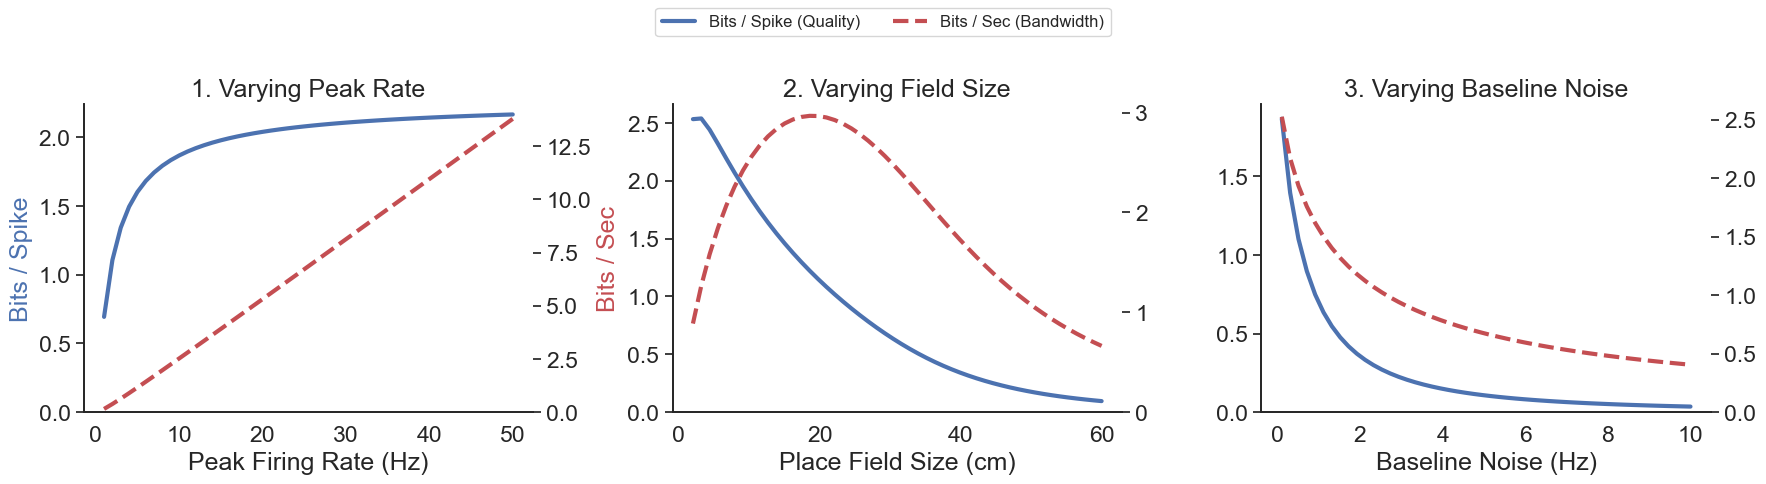

In [11]:

# Defining both mutual information formulas. 
def calculate_both_informations(firing_curve):
    # Assume uniform occupancy across a 200cm track
    p_occ = np.ones(len(firing_curve)) / len(firing_curve)
    
    avg_rate = np.sum(firing_curve * p_occ)
    if avg_rate == 0:
        return 0.0, 0.0
    
    info_spike = 0.0
    
    for i in range(len(firing_curve)):
        if firing_curve[i] > 0:
            ratio = firing_curve[i] / avg_rate
            info_spike += p_occ[i] * ratio * np.log2(ratio)
            
    # Bits per second 
    info_sec = info_spike * avg_rate 
    
    return info_spike, info_sec

# Helper function to generate a cell curve and return its info
def test_parameters(peak_rate, size, noise):
    track = np.arange(0, 200, 1.0)
    center = 100.0  
    
    # Mathematical curve: Gaussian Signal + Uniform Noise
    curve = peak_rate * np.exp(-((track - center)**2) / (2 * size**2)) + noise
    return calculate_both_informations(curve)

# Values to test
test_rates = np.linspace(1, 50, 50)      
test_sizes = np.linspace(2, 60, 50)      
test_noises = np.linspace(0.1, 10, 50)   

results_rate = np.array([test_parameters(pr, size=10, noise=0.1) for pr in test_rates])
results_size = np.array([test_parameters(peak_rate=10, size=sz, noise=0.1) for sz in test_sizes])
results_noise = np.array([test_parameters(peak_rate=10, size=10, noise=nz) for nz in test_noises])


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot: Varying Peak Rate
ax1 = axes[0]
line1 = ax1.plot(test_rates, results_rate[:, 0], 'b-', linewidth=3)[0]
ax1.set_xlabel("Peak Firing Rate (Hz)")
ax1.set_ylabel("Bits / Spike", color='b')
ax1.set_title("1. Varying Peak Rate")
ax1.set_ylim(bottom=0)

ax1_twin = ax1.twinx() 
line2 = ax1_twin.plot(test_rates, results_rate[:, 1], 'r--', linewidth=3)[0]
ax1_twin.set_ylabel("Bits / Sec", color='r')
ax1_twin.set_ylim(bottom=0) 

# Plot: Varying Place Field Size
ax2 = axes[1]
ax2.plot(test_sizes, results_size[:, 0], 'b-', linewidth=3)
ax2.set_xlabel("Place Field Size (cm)")
ax2.set_title("2. Varying Field Size")
ax2.set_ylim(bottom=0) 

ax2_twin = ax2.twinx()
ax2_twin.plot(test_sizes, results_size[:, 1], 'r--', linewidth=3)
ax2_twin.set_ylim(bottom=0) 
# Plot: Varying Baseline Noise
ax3 = axes[2]
ax3.plot(test_noises, results_noise[:, 0], 'b-', linewidth=3)
ax3.set_xlabel("Baseline Noise (Hz)")
ax3.set_title("3. Varying Baseline Noise")
ax3.set_ylim(bottom=0) # <--- Force Y-axis to start at 0

ax3_twin = ax3.twinx()
ax3_twin.plot(test_noises, results_noise[:, 1], 'r--', linewidth=3)
ax3_twin.set_ylim(bottom=0) 

# Add overarching legend 
fig.legend(handles=[line1, line2], 
           labels=["Bits / Spike (Quality)", "Bits / Sec (Bandwidth)"], 
           loc='upper center', 
           fontsize=12, 
           ncol=2)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()



## Mutual information outcomes: 
- Bits/ second: Tells us about the amount of information delivered by a neuron per second. 
- Bits per spike: Tells us about the spatial specificity of the neuron.  

### Varying Peak Rate:
- Bits/sec (red): As peak rate increases, the amount of information per second increases linearly (from 5Hz to 50 Hz the total information is 10 times greater)
- Bits/Spike (Blue): As firing rate increases and baseline noise stays constant (0.1Hz) the Signal to Noise Ratio improves. The quality of each spike (Bits/spikes) increases as well until it reaches a plateau.  

### Varying Field Size: 
- Bits/sec (red): Inverted U-shape. With tiny fields, spikes are assigned to a small extent of space, in which rarely fires (lowering the information per second). With massive fields the cell fires constantly, but the spikes give no spatial information. The peak represents the optimal place field size in which fields are large enoiugh to generate a decent number of spikes but small enough to remain spatially specific.
- Bits/Spike (Blue): Smaller place fields describe more accurately the position of the animal, while massive place fields increases uncertainty because the cell is active extensively over the track. 

### Varying Baseline Noise:
 - Bits/sec (red) and Bits/spike: When noise is high the cell could fire anywhere. The algorithm does not distinguish between true place fields and random noise spikes. Hence, the spatial selectivity drops drastically


## Exercise 3 - working with real data
---
Load the data from `linear_track_data.pickle`. It contains neural recordings from a mouse running on a linear track.
- `x` contains the position of the animal
- `t` contains the corresponding times, in seconds
- `spikes` contains a list of lists. Each list contains the timestamps of the spikes emitted by a neuron.

A - Visualiaze the position a s a function of time. Plot the spike of a selected cell in space.

B - Calculate the firing rate maps for all the cells, and plot them sorted by increasing peak positon.

C - Calculate the spatial information for each cell, and plot the distribution. Plot the firing rate maps of the 5 cells with lower spatial information, and the firing rate maps of the 5 cells with higher spatial information. Comment on the differences.

In [12]:

# load the data
data_path = 'data/linear_track_data.pickle'


with open(data_path, 'rb') as handle:
    real_data = pickle.load(handle)

# Unpack the variables 
x = real_data['x']           
t = real_data['t']          
spikes = real_data['spikes'] 
print(f"Data successfully loaded! Track length: {len(x)} frames. Cells recorded: {len(spikes)}.")


Data successfully loaded! Track length: 37837 frames. Cells recorded: 72.


C:\Users\4bmar\AppData\Local\Temp\ipykernel_3332\1766695800.py:6: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  real_data = pickle.load(handle)


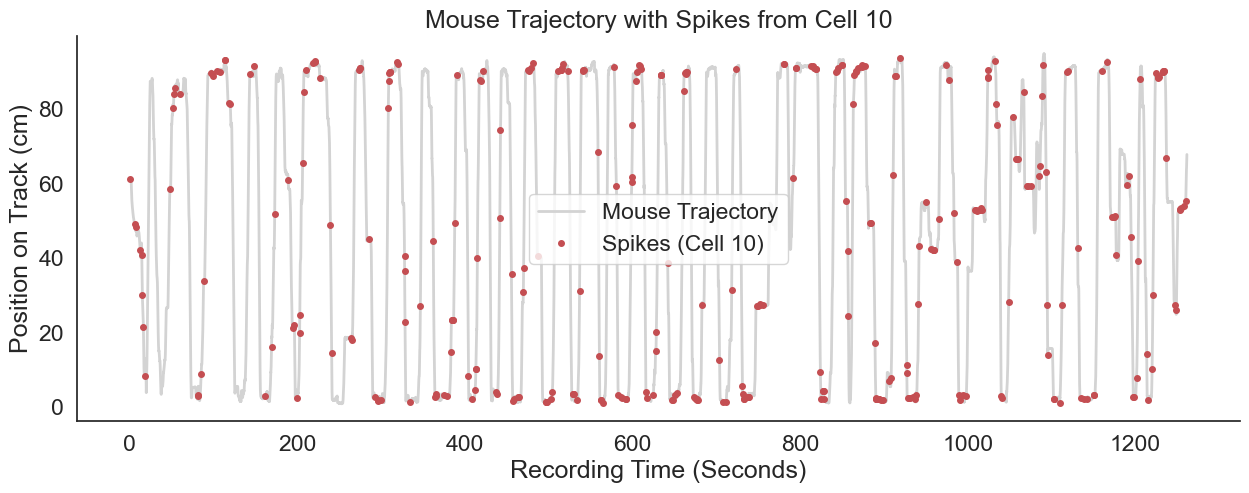

In [13]:

# Select which cell 
selected_cell = 10
spike_times = spikes[selected_cell]

# Interpolate
spike_locations = np.interp(spike_times, t, x)

# Visualize the data
plt.figure(figsize=(15, 5))


plt.plot(t, x, color='lightgray', label="Mouse Trajectory", linewidth=2)


plt.plot(spike_times, spike_locations, 'r.', label=f"Spikes (Cell {selected_cell})", markersize=8)

plt.xlabel("Recording Time (Seconds)")
plt.ylabel("Position on Track (cm)")
plt.title(f"Mouse Trajectory with Spikes from Cell {selected_cell}")
plt.legend()
plt.show()


## Observations:
The cell selected does not have an specificity of firing at a designed place. It seems to fire more frequently in the extremes of the linear track (where it may be resting and spending more time).  If we want to know the specificity of the firing we should look at the occupancy normalized firing rate map. 

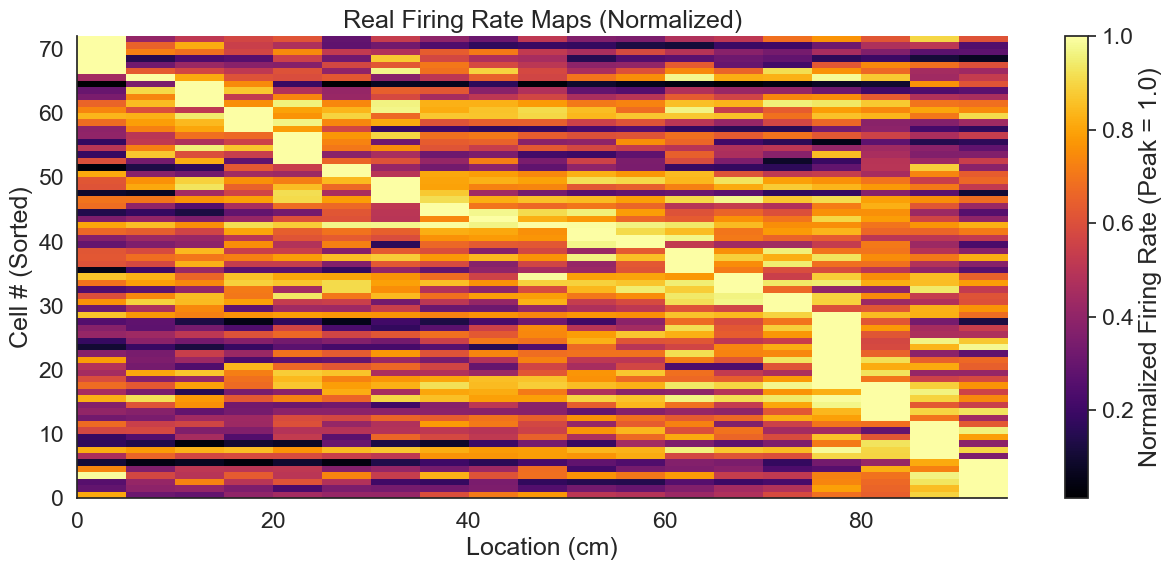

In [14]:

# Track length
max_x = np.max(x)
space_bins = np.arange(0., max_x + 5.0, 5.0)

# Calculate fps
fps = 1.0 / np.median(np.diff(t))

# Calculate Occupancy
occupancy = np.histogram(x, space_bins)[0] / fps
occupancy[occupancy == 0] = 0.001 

# histograms
spike_positions = [np.interp(s, t, x) for s in spikes]
spikes_hist = [np.histogram(s, space_bins)[0] for s in spike_positions]
spikes_hist = np.vstack(spikes_hist).astype(np.float64)

#  Firing Rate (Hz)
firing_rate_maps = spikes_hist / occupancy 

# Normalize the maps
max_rates = np.max(firing_rate_maps, axis=1, keepdims=True)

max_rates[max_rates == 0] = 1.0 
# Divide each cell's map by its own peak rate
normalized_maps = firing_rate_maps / max_rates

# Sorting
peak_locations = normalized_maps.argmax(axis=1)
ix = np.argsort(peak_locations)

# Plot
plt.figure(figsize=(15, 6))


plt.imshow(normalized_maps[ix, :], cmap='inferno', extent=[0, max_x, 0, len(spikes)], aspect='auto')

plt.xlabel('Location (cm)')
plt.ylabel('Cell # (Sorted)')
plt.title('Real Firing Rate Maps (Normalized)')
plt.colorbar(label='Normalized Firing Rate (Peak = 1.0)')
plt.show()


## Note:
I normalized the firing rate map because I observed that with raw data will not look as a firing rate map with the prototypical diagonal sequence (see below). This is likely due to the different properties of different neurons in biological real data (while cell 10 can fire at 50 HZ, cell 30 can peak at 3Hz)

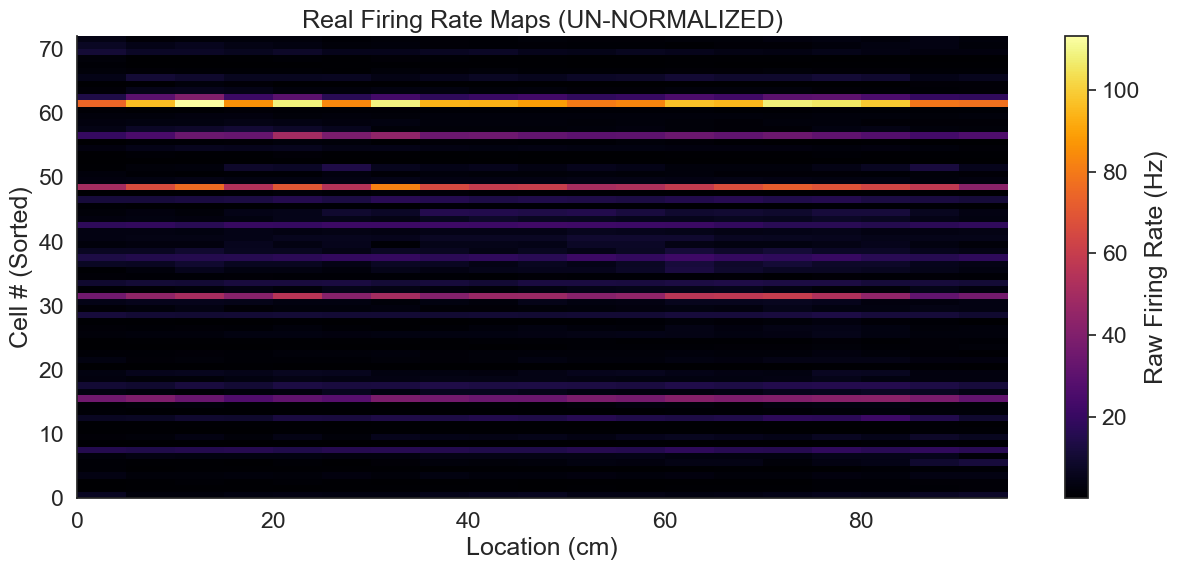

In [15]:
# Without normalizing 
plt.figure(figsize=(15, 6))

plt.imshow(firing_rate_maps[ix, :], cmap='inferno', extent=[0, max_x, 0, len(spikes)], aspect='auto')

plt.xlabel('Location (cm)')
plt.ylabel('Cell # (Sorted)')
plt.title('Real Firing Rate Maps (UN-NORMALIZED)')
plt.colorbar(label='Raw Firing Rate (Hz)')
plt.show()


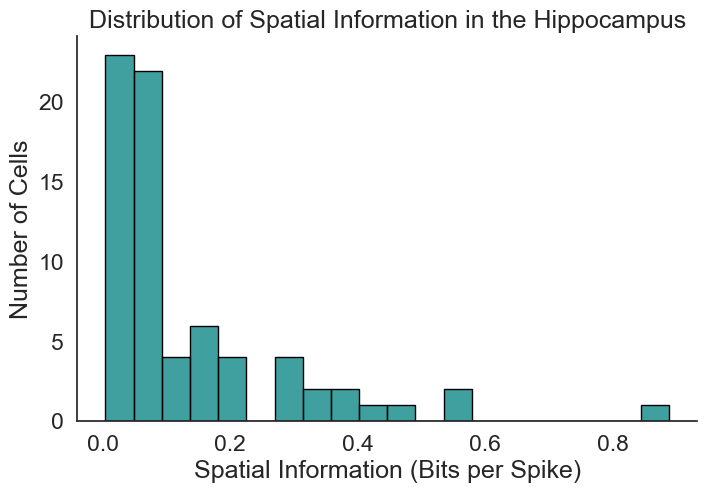

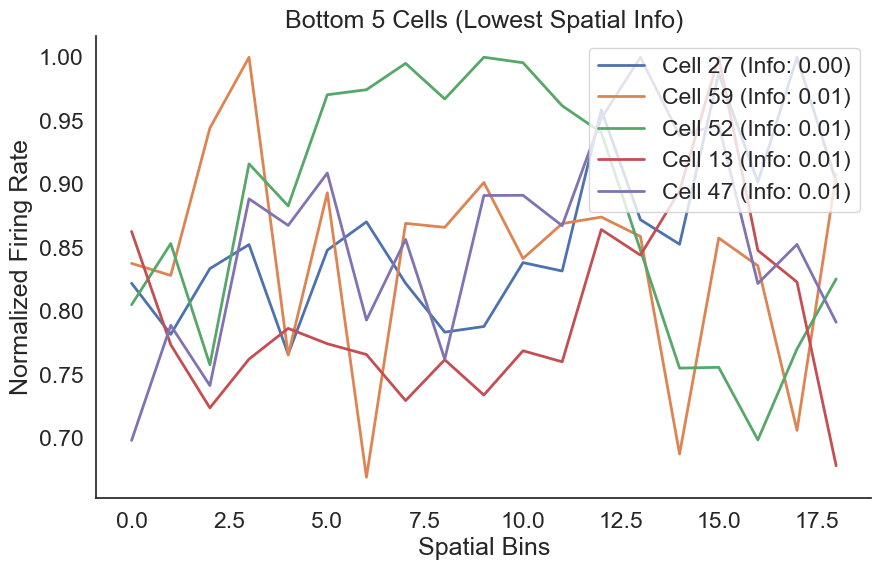

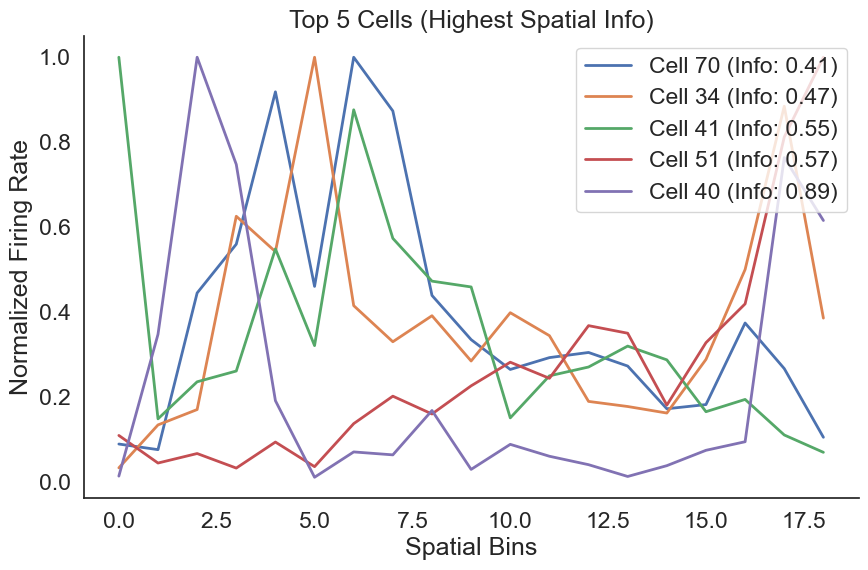

In [16]:
# Mutual information
def calculate_mutual_information(firing_rate_map, occupancy_probability):
    global_average_rate = np.sum(firing_rate_map * occupancy_probability)
    if global_average_rate == 0:
        return 0.0
    
    total_information = 0.0
    for i in range(len(firing_rate_map)):
        local_rate = firing_rate_map[i]
        local_prob = occupancy_probability[i]
        if local_rate > 0:
            rate_ratio = local_rate / global_average_rate
            total_information += local_prob * rate_ratio * np.log2(rate_ratio)
            
    return total_information


p_occ = occupancy / np.sum(occupancy)

# Calculate spatial information
spatial_information = np.zeros(len(spikes))
for i in range(len(spikes)):
    spatial_information[i] = calculate_mutual_information(firing_rate_maps[i, :], p_occ)

# PTSH plot 
plt.figure(figsize=(8, 5))


sns.histplot(spatial_information, bins=20, color='teal', edgecolor='black', kde=False)

plt.xlabel("Spatial Information (Bits per Spike)")
plt.ylabel("Number of Cells")
plt.title("Distribution of Spatial Information in the Hippocampus")
plt.show()

# Find the 5 worst and 5 best cells
sorted_info_indices = np.argsort(spatial_information)
bottom_5_indices = sorted_info_indices[:5]  
top_5_indices = sorted_info_indices[-5:]    

# Bottom 5 cells
plt.figure(figsize=(10, 6))
for idx in bottom_5_indices:
    plt.plot(normalized_maps[idx, :], label=f"Cell {idx} (Info: {spatial_information[idx]:.2f})", linewidth=2)
plt.title("Bottom 5 Cells (Lowest Spatial Info)")
plt.xlabel("Spatial Bins")
plt.ylabel("Normalized Firing Rate")
plt.legend(loc='upper right')
plt.show()

# Top 5 cells 
plt.figure(figsize=(10, 6))
for idx in top_5_indices:
    plt.plot(normalized_maps[idx, :], label=f"Cell {idx} (Info: {spatial_information[idx]:.2f})", linewidth=2)
plt.title("Top 5 Cells (Highest Spatial Info)")
plt.xlabel("Spatial Bins")
plt.ylabel("Normalized Firing Rate")
plt.legend(loc='upper right')
plt.show()

As we can see the spatial information overall is low in this dataset (PSTH plot). Nevertheless, we can see that the cells with highest spatial information present a peak of firing rate in an specific spatial bin (e.g cell 40 at 2.5), which means a higher spatial information. 
However, lowest spatial information cells have unspecific firing rates all over the bins. Moreover, these cells fire at high firing rates constantly (y-axis of the plot), which reduces drastically the signal to noise ratio and spatial information. 